<a href="https://www.kaggle.com/code/nicapotato/ai-model-arena-rankings-analysis?scriptVersionId=340389794" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Guided Numeric Exploration — AI Model Arena Rankings (2023–2026)
_Human-preference Elo snapshots across text, vision, webdev, and search arenas_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [riyagarg0314/ai-model-arena-rankings-2023-2026](https://www.kaggle.com/datasets/riyagarg0314/ai-model-arena-rankings-2023-2026)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Snapshot Mix](#Univariate)** <br>
**4. [Frontier Elo Over Time](#Frontier)** <br>
**5. [Organizations and Licenses](#Orgs)** <br>
**6. [Votes, Uncertainty, Cross-Subset](#Votes)** <br>
**7. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
Historical Chatbot Arena / LMArena Elo rankings (~97k rows) from May 2023 through July 2026. Each row is a model on a published leaderboard snapshot for one `subset` arena (`text`, `text_style_control`, `vision`, `webdev`, `search`). `category` is always `overall`.

Ratings are Bradley-Terry / Elo-style human preference scores with optional CI bounds and vote counts. Organization is ~3% null — left as missing, not imputed. Licenses are noisy strings (Apache spelling variants, vendor community licenses); we normalize lightly for univariate plots and map to openness tiers for open vs closed comparisons. The file ships with a double extension (`ai_model_arena_rankings.csv.csv`).



# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
KAGGLE_SLUG = "riyagarg0314/ai-model-arena-rankings-2023-2026"
EXPECTED_COLS = [
    "model_name", "organization", "license", "rating", "rating_lower", "rating_upper",
    "variance", "vote_count", "rank", "category", "leaderboard_publish_date", "subset",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    patterns = ["ai_model_arena_rankings.csv.csv", "ai_model_arena_rankings.csv", "*arena*rankings*.csv*"]
    if kaggle_root.exists():
        for pat in patterns:
            hits = list(kaggle_root.rglob(pat))
            if hits:
                return hits[0]
        raise AssertionError("arena rankings csv not under /kaggle/input")
    for name in ["ai_model_arena_rankings.csv.csv", "ai_model_arena_rankings.csv"]:
        local = Path("data") / name
        if local.exists():
            return local
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob("*arena*rankings*.csv*"))
    assert hits, f"arena rankings csv not under {root}"
    return hits[0]


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 97377, f"expected 97377 rows, got {len(df)}"
assert (df["category"] == "overall").all()

df["leaderboard_publish_date"] = pd.to_datetime(df["leaderboard_publish_date"], errors="coerce")
assert df["leaderboard_publish_date"].notna().all()
df["ci_width"] = df["rating_upper"] - df["rating_lower"]

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Missing Values:", df.isnull().sum().sum())
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Date range:", df["leaderboard_publish_date"].min().date(), "→", df["leaderboard_publish_date"].max().date())
print("Snapshots:", df["leaderboard_publish_date"].nunique())
print("Models:", df["model_name"].nunique())
print("subset:", df["subset"].value_counts().to_dict())
print("organization null share: {:.1%}".format(df["organization"].isna().mean()))

text = df[df["subset"] == "text"].copy()
assert len(text) > 40_000


CSV: /kaggle/input/datasets/riyagarg0314/ai-model-arena-rankings-2023-2026/ai_model_arena_rankings.csv.csv
Missing Values: 5143
Dataframe Dimension: 97377 Rows, 13 Columns
Date range: 2023-05-08 → 2026-07-10
Snapshots: 247
Models: 461
subset: {'text': 45123, 'text_style_control': 40141, 'vision': 8229, 'webdev': 3292, 'search': 592}
organization null share: 3.6%


**Code Explanation and Reasoning:** <br>
Filename resolution tolerates the double `.csv.csv` quirk. `category` is asserted to be entirely `overall`. Dates are parsed; CI width is derived only where bounds exist. The `text` subset is the primary panel for frontier plots.


In [3]:
df.sample(5, random_state=7)


,model_name,organization,license,rating,rating_lower,rating_upper,variance,vote_count,rank,category,leaderboard_publish_date,subset,ci_width
6759,chatglm3-6b,Tsinghua,Apache-2.0,955.181934,945.264869,964.539291,25.355662,4765.0,136.0,overall,2024-12-15,text,19.274423
35385,claude-3-5-sonnet-20240620,anthropic,Proprietary,1280.642152,1277.134395,1284.149909,3.203044,82419.0,194.0,overall,2026-04-10,text,7.015515
15737,llama-2-7b-chat,meta,Llama 2 Community,1061.235834,1054.471608,1068.000060,11.910777,14532.0,192.0,overall,2025-07-25,text,13.528453
33437,phi-3-medium-4k-instruct,microsoft,MIT,1137.523608,1132.306974,1142.740242,7.084098,25055.0,264.0,overall,2026-03-20,text,10.433268
81922,solar-10.7b-instruct-v1.0,NaN,CC-BY-NC-4.0,1151.118866,1137.933109,1164.304623,45.259935,4155.0,318.0,overall,2026-05-19,text_style_control,26.371513


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Null", ascending=False))
df[["rating", "vote_count", "rank", "ci_width"]].describe().T.round(2)


,Column,Unique,Null
1,organization,66,3477
4,rating_lower,93752,307
7,vote_count,19264,307
6,variance,93749,307
5,rating_upper,93752,307
12,ci_width,93749,307
2,license,40,131
3,rating,93794,0
0,model_name,461,0
8,rank,374,0


,count,mean,std,min,25%,50%,75%,max
rating,97377.0,1232.58,145.45,789.0,1125.96,1240.19,1348.77,1664.99
vote_count,97070.0,23586.33,27389.38,54.0,5243.00,12857.00,32191.00,202735.00
rank,97377.0,119.16,89.94,1.0,43.00,99.00,180.00,374.00
ci_width,97070.0,14.14,7.35,0.0,8.65,12.51,18.26,104.54


**Interpretation** <br>
This is a panel: models × snapshots × arena subsets. Nulls concentrate in CI/vote fields on early snapshots and in organization for some entries.


# **3. Univariate Snapshot Mix:** <a id="Univariate"></a>

Row counts by arena, Elo shape on text, and organization presence — then a dedicated look at **license type** as a categorical feature (raw labels and a cleaned family).



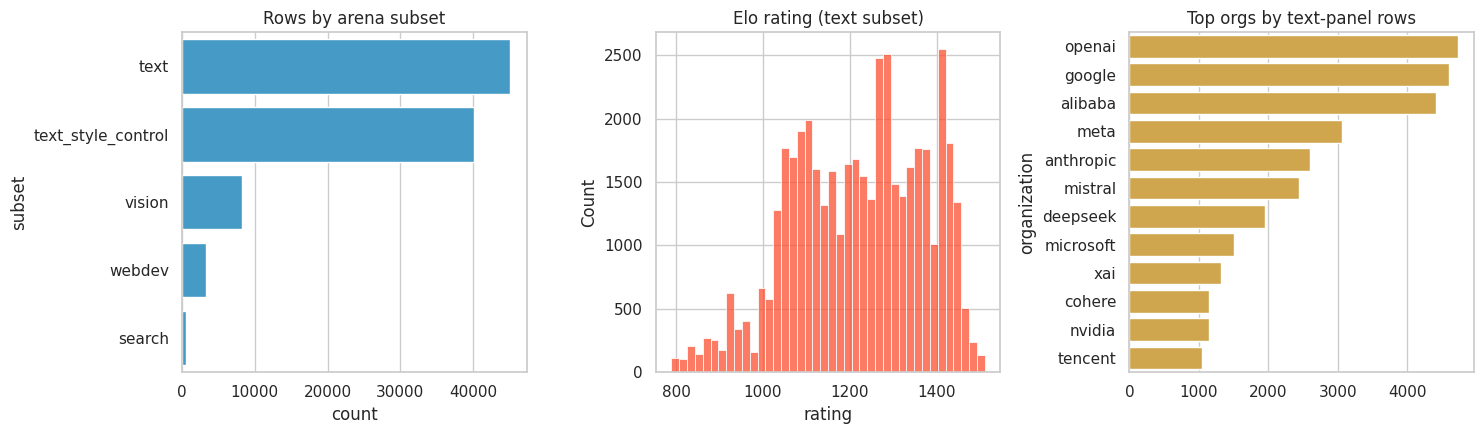

In [5]:
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(data=df, y="subset", order=df["subset"].value_counts().index, ax=ax[0], color="#30a2da")
ax[0].set_title("Rows by arena subset")
sns.histplot(text["rating"], bins=40, ax=ax[1], color="#fc4f30")
ax[1].set_title("Elo rating (text subset)")
top_org = text["organization"].value_counts().head(12)
sns.barplot(x=top_org.values, y=top_org.index, ax=ax[2], color="#e5ae38")
ax[2].set_title("Top orgs by text-panel rows")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Text and style-control dominate row counts because they have longer histories. Org bar counts are appearance-weighted (more snapshots × more models), not unique-model counts. License is the next univariate cut — it is categorical with ~40 raw labels and spelling duplicates.



Raw license labels: 40
Normalized license labels: 33
Missing license rows: 131
Models with >1 distinct raw license: 4


,rows,row_share,unique_models,model_share
license_norm,,,,
Proprietary,39898,0.410,226.0,0.490
Apache 2.0,16993,0.175,76.0,0.165
MIT,9130,0.094,48.0,0.104
Llama 2 Community,3775,0.039,10.0,0.022
Qianwen LICENSE,3760,0.039,12.0,0.026
Gemma,3453,0.035,11.0,0.024
CC-BY-NC-4.0,3377,0.035,12.0,0.026
Non-commercial,2667,0.027,7.0,0.015
DeepSeek,1607,0.017,5.0,0.011


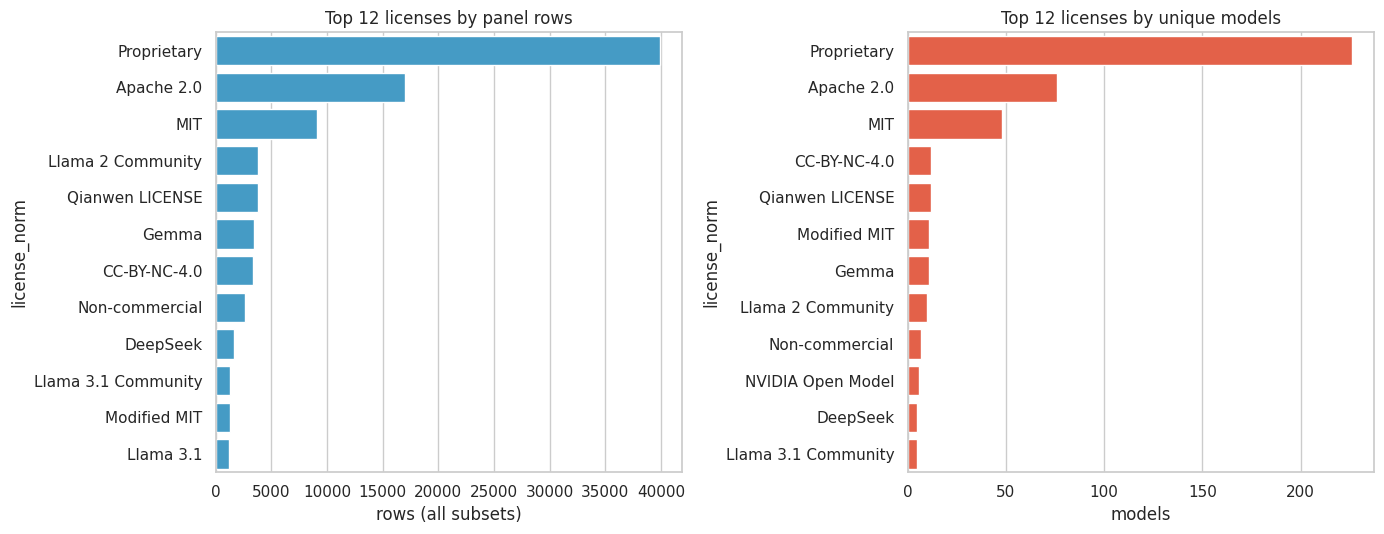

In [6]:
# License univariate: normalize common spelling duplicates, then count
LICENSE_ALIASES = {
    "Apache-2.0": "Apache 2.0",
    "Gemma license": "Gemma",
    "DeepSeek License": "DeepSeek",
    "Nvidia Open Model": "NVIDIA Open Model",
    "Nvidia Open": "NVIDIA Open Model",
    "Nvidia": "NVIDIA Open Model",
    "Qwen": "Qianwen LICENSE",
}


def normalize_license(s: object) -> str:
    if pd.isna(s):
        return "Missing"
    s = str(s).strip()
    return LICENSE_ALIASES.get(s, s)


df["license_norm"] = df["license"].map(normalize_license)
text["license_norm"] = text["license"].map(normalize_license)

# Unique-model view (one row per model_name; modal license if a model flips)
model_lic = (
    df.groupby("model_name")["license_norm"]
    .agg(lambda s: s.mode(dropna=False).iloc[0])
    .rename("license_norm")
    .reset_index()
)
assert model_lic["model_name"].is_unique

lic_rows = df["license_norm"].value_counts()
lic_models = model_lic["license_norm"].value_counts()
print("Raw license labels:", df["license"].nunique(dropna=False))
print("Normalized license labels:", df["license_norm"].nunique())
print("Missing license rows:", int((df["license_norm"] == "Missing").sum()))
print("Models with >1 distinct raw license:", int(df.groupby("model_name")["license"].nunique().gt(1).sum()))
display(
    pd.DataFrame({
        "rows": lic_rows,
        "row_share": (lic_rows / lic_rows.sum()).round(3),
        "unique_models": lic_models,
        "model_share": (lic_models / lic_models.sum()).round(3),
    })
    .fillna(0)
    .sort_values("rows", ascending=False)
    .head(15)
)

f, ax = plt.subplots(1, 2, figsize=(14, 5.5))
top_n = 12
sns.barplot(
    x=lic_rows.head(top_n).values,
    y=lic_rows.head(top_n).index,
    ax=ax[0],
    color="#30a2da",
)
ax[0].set_title(f"Top {top_n} licenses by panel rows")
ax[0].set_xlabel("rows (all subsets)")
sns.barplot(
    x=lic_models.head(top_n).values,
    y=lic_models.head(top_n).index,
    ax=ax[1],
    color="#fc4f30",
)
ax[1].set_title(f"Top {top_n} licenses by unique models")
ax[1].set_xlabel("models")
plt.tight_layout()
plt.show()



**How to Interpret:** <br>
Left panel is appearance-weighted (long-lived models inflate counts). Right panel answers "how many distinct models carry this license?" Proprietary is ~41% of rows but ~49% of unique models — open-weight licenses are more fragmented across many named variants (Llama / Gemma / Qwen / Apache / MIT). Apache spelling (`Apache 2.0` vs `Apache-2.0`) is merged; vendor community licenses stay separate until the openness tier map below.



# **4. Frontier Elo Over Time:** <a id="Frontier"></a>


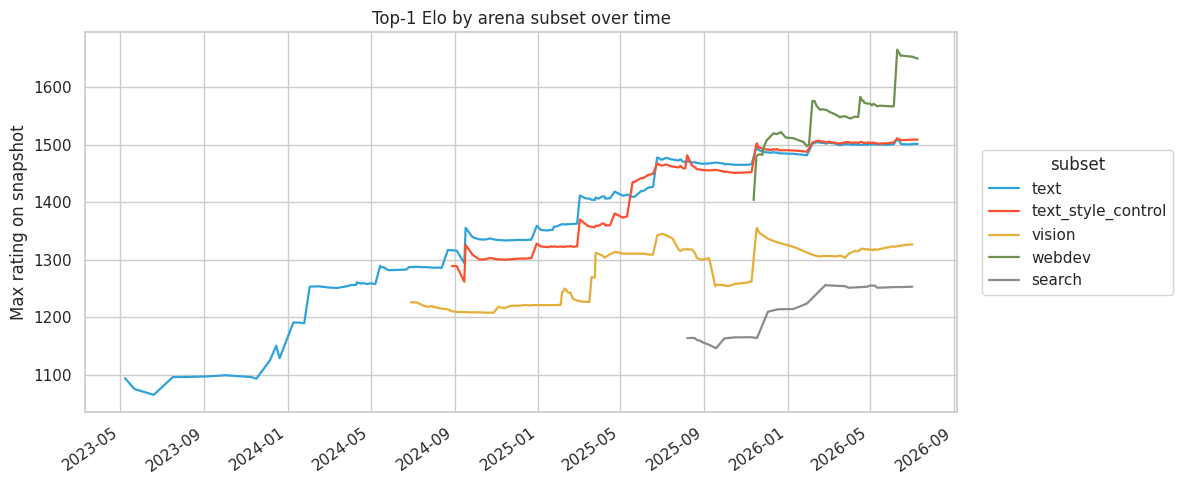

,leaderboard_publish_date,model_name,organization,rating,rank
211,2026-05-14,claude-opus-4-6-thinking,anthropic,1499.640926,1.0
212,2026-05-18,claude-opus-4-6-thinking,anthropic,1499.870938,1.0
213,2026-05-19,claude-opus-4-6-thinking,anthropic,1500.036179,1.0
214,2026-05-27,claude-opus-4-6-thinking,anthropic,1499.317340,1.0
215,2026-06-03,claude-opus-4-6-thinking,anthropic,1500.393573,1.0
216,2026-06-04,claude-opus-4-6-thinking,anthropic,1500.346426,1.0
217,2026-06-05,claude-opus-4-6-thinking,anthropic,1500.547773,1.0
218,2026-06-10,claude-opus-4-6-thinking,anthropic,1510.631267,1.0
219,2026-06-16,claude-opus-4-6-thinking,anthropic,1500.668125,1.0
220,2026-06-25,claude-opus-4-6-thinking,anthropic,1500.252515,1.0


Unique text #1 models: 22
Top #1 holders: {'claude-opus-4-6-thinking': 40, 'gemini-2.5-pro': 27, 'gpt-4o-2024-05-13': 24, 'gemini-3-pro': 20, 'o1-preview': 18, 'o3-2025-04-16': 13, 'claude-opus-4-6': 13, 'deepseek-r1': 11}


In [7]:
def frontier_series(frame: pd.DataFrame, top_k: int = 1) -> pd.DataFrame:
    g = (
        frame.groupby("leaderboard_publish_date", as_index=False)
        .apply(lambda d: d.nlargest(top_k, "rating")[["leaderboard_publish_date", "rating", "model_name", "organization"]],
               include_groups=False)
    )
    # groupby.apply can nest; normalize
    if isinstance(g, pd.Series):
        g = g.reset_index(drop=True)
    return g.reset_index(drop=True)


# Simpler: top-1 and median rating per date × subset
frontier = (
    df.groupby(["subset", "leaderboard_publish_date"])["rating"]
    .agg(top1="max", median="median", n="count")
    .reset_index()
)

f, ax = plt.subplots(figsize=(12, 5))
for subset, color in zip(
    ["text", "text_style_control", "vision", "webdev", "search"],
    ["#30a2da", "#fc4f30", "#e5ae38", "#6d904f", "#8b8b8b"],
):
    s = frontier[frontier["subset"] == subset].sort_values("leaderboard_publish_date")
    if s.empty:
        continue
    ax.plot(s["leaderboard_publish_date"], s["top1"], label=subset, color=color, lw=1.6)
ax.set_title("Top-1 Elo by arena subset over time")
ax.set_ylabel("Max rating on snapshot")
ax.legend(title="subset", bbox_to_anchor=(1.02, 0.5), loc="center left")
ax.tick_params(axis="x", labelrotation=35)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

# Who holds #1 on text over time
text_sorted = text.sort_values(["leaderboard_publish_date", "rank"])
leaders = text_sorted.groupby("leaderboard_publish_date", as_index=False).first()[
    ["leaderboard_publish_date", "model_name", "organization", "rating", "rank"]
]
assert (leaders["rank"] == 1).all() or leaders["rank"].isna().any()
display(leaders.tail(12))
print("Unique text #1 models:", leaders["model_name"].nunique())
print("Top #1 holders:", leaders["model_name"].value_counts().head(8).to_dict())



**How to Interpret:** <br>
Rising top-1 Elo traces the preference frontier. Subsets are not directly comparable as absolute Elo scales may differ — compare shapes and leadership churn, not raw cross-arena points.


# **5. Organizations and Licenses:** <a id="Orgs"></a>

Org competitiveness on the latest board, **individual model Elo careers** over time, then a deeper **open vs closed** cut: openness tiers from license text, Elo distributions, frontier composition over time, and whether open-weight models close the gap at the top of the text arena.



Latest text snapshot: 2026-07-10 n= 374


,n,mean_rating,best
organization,,,
anthropic,28,1386.6,1501.2
google,36,1300.6,1480.1
meta,19,1187.9,1477.9
alibaba,40,1325.1,1475.4
openai,42,1351.9,1468.6
zai,14,1386.7,1467.4
baidu,4,1446.1,1467.3
xiaomi,6,1425.7,1462.4
moonshot,6,1414.2,1455.6


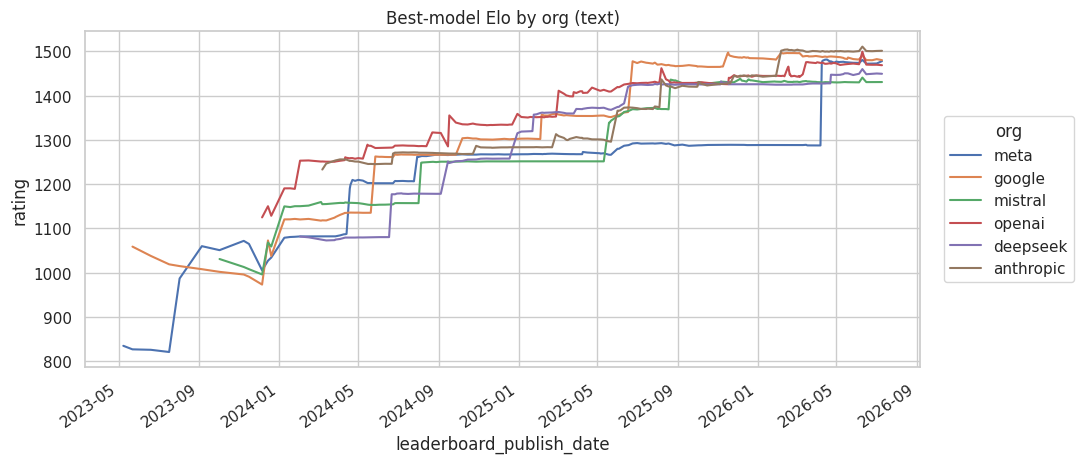

In [8]:
# Latest text snapshot org mean rating among ranked models
latest_date = text["leaderboard_publish_date"].max()
latest = text[text["leaderboard_publish_date"] == latest_date].copy()
print("Latest text snapshot:", latest_date.date(), "n=", len(latest))

org_stats = (
    latest.dropna(subset=["organization"])
    .groupby("organization")
    .agg(n=("model_name", "count"), mean_rating=("rating", "mean"), best=("rating", "max"))
    .sort_values("best", ascending=False)
    .head(15)
)
display(org_stats.round(1))

# Org trajectory: best model Elo over time (top orgs)
focus_orgs = ["openai", "google", "anthropic", "meta", "mistral", "deepseek"]
best_by_org = (
    text.dropna(subset=["organization"])
    .assign(organization=lambda d: d["organization"].str.lower())
    .query("organization in @focus_orgs")
    .groupby(["leaderboard_publish_date", "organization"])["rating"]
    .max()
    .reset_index()
)
f, ax = plt.subplots(figsize=(11, 4.8))
sns.lineplot(
    data=best_by_org, x="leaderboard_publish_date", y="rating", hue="organization", ax=ax,
)
ax.set_title("Best-model Elo by org (text)")
ax.legend(title="org", bbox_to_anchor=(1.02, 0.5), loc="center left")
ax.tick_params(axis="x", labelrotation=35)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()



**How to Interpret:** <br>
Latest-snapshot org tables show who fields competitive models *now*. Best-model trajectories show whether an org's frontier entry keeps pace — not the quality of their average release. License openness is a separate axis from org brand — Meta/Mistral/DeepSeek can be open-weight while OpenAI/Anthropic stay proprietary. Next: individual **model** Elo paths (orgs collapse several named releases into one line).



Focus models: latest-board top-8 ∪ most frequent historical top-10 models


,first_seen,last_seen,n_snapshots,peak_rating,end_rating,organization,license_norm,delta_peak_to_end
model_name,,,,,,,,
claude-opus-4-6-thinking,2026-02-06,2026-07-10,53,1510.6,1501.2,anthropic,Proprietary,-9.5
claude-opus-4-6,2026-02-06,2026-07-10,53,1506.7,1497.5,anthropic,Proprietary,-9.2
claude-opus-4-7-thinking,2026-04-17,2026-07-10,24,1498.4,1490.2,anthropic,Proprietary,-8.2
gemini-3-pro,2025-11-16,2026-07-10,73,1497.2,1479.5,google,Proprietary,-17.7
claude-fable-5,2026-06-10,2026-07-10,5,1496.7,1495.1,anthropic,Proprietary,-1.6
gemini-3.1-pro-preview,2026-02-06,2026-07-10,53,1496.7,1479.0,google,Proprietary,-17.7
claude-opus-4-7,2026-04-17,2026-07-10,24,1489.7,1482.4,anthropic,Proprietary,-7.3
gemini-3.5-flash-high,2026-07-10,2026-07-10,1,1480.1,1480.1,google,Proprietary,0.0
gemini-2.5-pro,2025-06-24,2026-07-10,100,1477.5,1457.4,google,Proprietary,-20.1


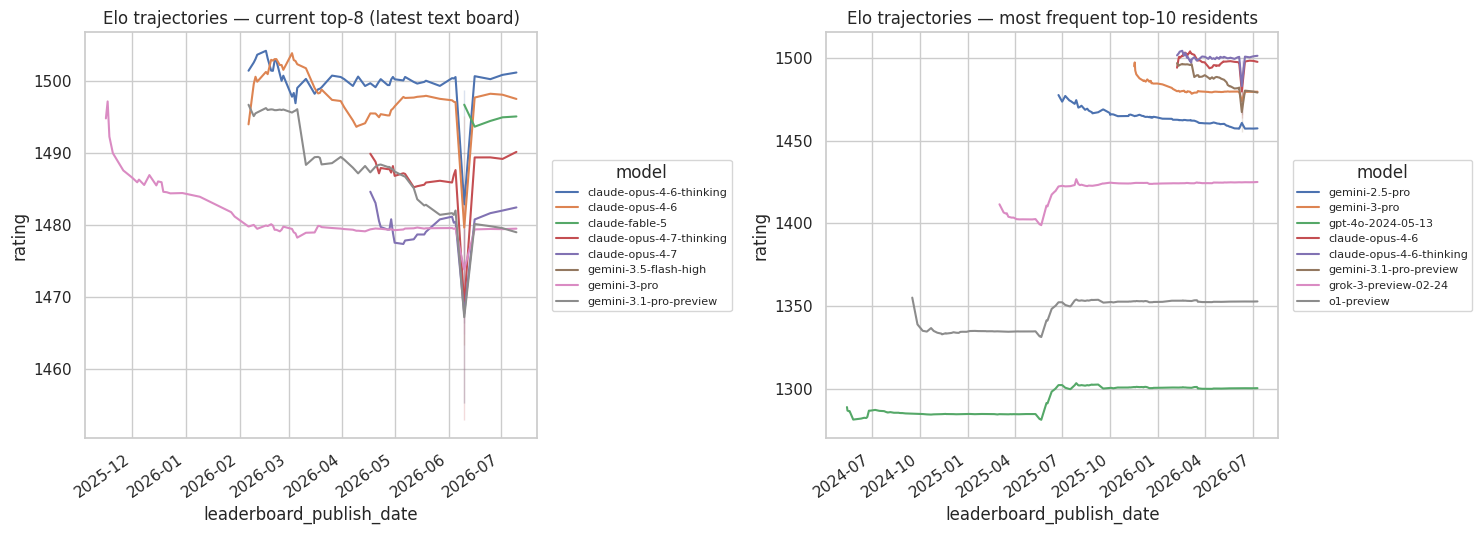

Models with ≥6 text snapshots: 371; median net Elo change=7.1; median drawdown from peak=-8.7


,n,first_rating,last_rating,net_change,peak,kind
model_name,,,,,,
llama-3.1-nemotron-ultra-253b-v1,100,1221.2,1319.6,98.4,1322.3,biggest risers
llama-2-13b-chat,219,987.0,1084.6,97.6,1094.2,biggest risers
llama-2-7b-chat,219,961.0,1053.6,92.6,1061.6,biggest risers
solar-10.7b-instruct-v1.0,212,993.6,1083.2,89.6,1096.8,biggest risers
gpt-4-0613,214,1100.3,1186.2,85.9,1194.1,biggest risers
gpt-4-0314,214,1125.0,1206.2,81.2,1212.1,biggest risers
yi-34b-chat,214,1048.2,1128.6,80.4,1135.2,biggest risers
dolphin-2.2.1-mistral-7b,199,1003.0,1081.1,78.1,1089.3,biggest risers
gpt-5-high,96,1461.8,1405.5,-56.3,1465.1,biggest fallers


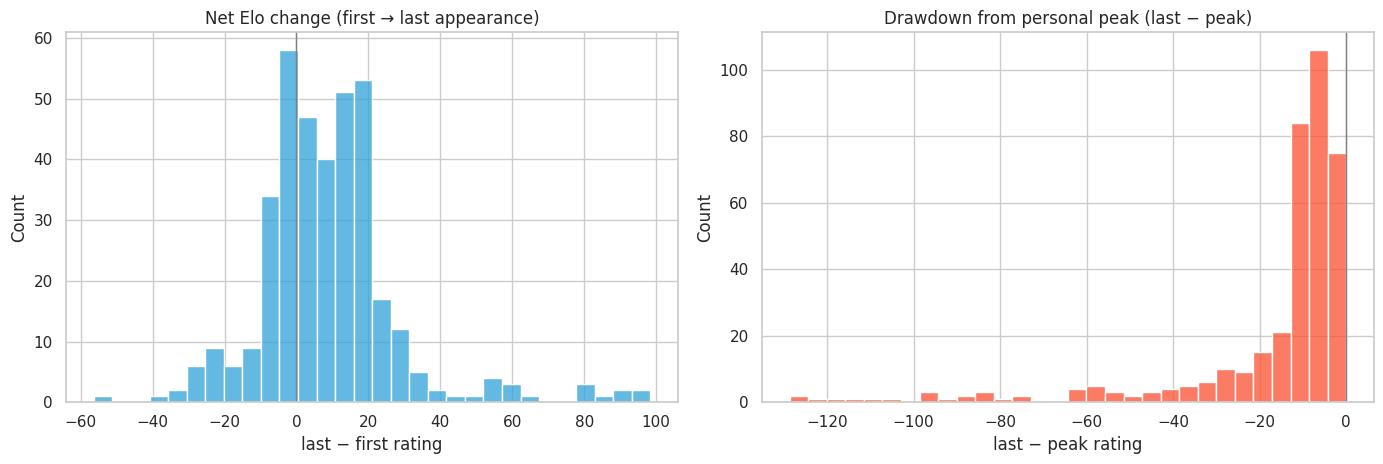

In [9]:
# Model-level Elo over time (text) — named releases, not org envelopes
# Focus set: current top models + historically frequent top-10 residents
latest_top = (
    latest.sort_values("rating", ascending=False)
    .head(8)["model_name"]
    .tolist()
)
# Models that appear most often in the text top-10 across snapshots
top10_freq = (
    text[text["rank"].notna() & (text["rank"] <= 10)]
    .groupby("model_name")
    .size()
    .sort_values(ascending=False)
)
historic_top = top10_freq.head(8).index.tolist()
focus_models = list(dict.fromkeys(latest_top + historic_top))  # preserve order, unique
assert len(focus_models) >= 8

model_traj = text[text["model_name"].isin(focus_models)].copy()
assert model_traj["model_name"].nunique() == len(focus_models)

# Tenure / peak summary for focus models (`last` after date sort)
model_summary = (
    model_traj.sort_values("leaderboard_publish_date")
    .groupby("model_name")
    .agg(
        first_seen=("leaderboard_publish_date", "min"),
        last_seen=("leaderboard_publish_date", "max"),
        n_snapshots=("leaderboard_publish_date", "nunique"),
        peak_rating=("rating", "max"),
        end_rating=("rating", "last"),
        organization=("organization", "last"),
        license_norm=("license_norm", "last"),
    )
    .sort_values("peak_rating", ascending=False)
)
model_summary["delta_peak_to_end"] = model_summary["end_rating"] - model_summary["peak_rating"]
print("Focus models: latest-board top-8 ∪ most frequent historical top-10 models")
display(model_summary.round(1))

f, ax = plt.subplots(1, 2, figsize=(15, 5.5))
# Left: current frontier names
sns.lineplot(
    data=model_traj[model_traj["model_name"].isin(latest_top)],
    x="leaderboard_publish_date",
    y="rating",
    hue="model_name",
    ax=ax[0],
    hue_order=latest_top,
)
ax[0].set_title("Elo trajectories — current top-8 (latest text board)")
ax[0].legend(title="model", bbox_to_anchor=(1.02, 0.5), loc="center left", fontsize=8)
ax[0].tick_params(axis="x", labelrotation=35)
for label in ax[0].get_xticklabels():
    label.set_horizontalalignment("right")

# Right: historically sticky top-10 names (may include retired leaders)
sns.lineplot(
    data=model_traj[model_traj["model_name"].isin(historic_top)],
    x="leaderboard_publish_date",
    y="rating",
    hue="model_name",
    ax=ax[1],
    hue_order=historic_top,
)
ax[1].set_title("Elo trajectories — most frequent top-10 residents")
ax[1].legend(title="model", bbox_to_anchor=(1.02, 0.5), loc="center left", fontsize=8)
ax[1].tick_params(axis="x", labelrotation=35)
for label in ax[1].get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

# Rise/fall: for every text model with ≥6 snapshots, rating change from first to last appearance
career = (
    text.sort_values("leaderboard_publish_date")
    .groupby("model_name")
    .agg(
        n=("rating", "count"),
        first_rating=("rating", "first"),
        last_rating=("rating", "last"),
        peak=("rating", "max"),
        first_date=("leaderboard_publish_date", "min"),
        last_date=("leaderboard_publish_date", "max"),
    )
)
career = career[career["n"] >= 6].copy()
career["net_change"] = career["last_rating"] - career["first_rating"]
career["drawdown_from_peak"] = career["last_rating"] - career["peak"]
print(
    f"Models with ≥6 text snapshots: {len(career)}; "
    f"median net Elo change={career['net_change'].median():.1f}; "
    f"median drawdown from peak={career['drawdown_from_peak'].median():.1f}"
)
display(
    pd.concat([
        career.nlargest(8, "net_change")[["n", "first_rating", "last_rating", "net_change", "peak"]].assign(kind="biggest risers"),
        career.nsmallest(8, "net_change")[["n", "first_rating", "last_rating", "net_change", "peak"]].assign(kind="biggest fallers"),
    ]).round(1)
)

f, ax = plt.subplots(1, 2, figsize=(14, 4.8))
sns.histplot(career["net_change"], bins=30, ax=ax[0], color="#30a2da")
ax[0].axvline(0, color="gray", lw=1)
ax[0].set_title("Net Elo change (first → last appearance)")
ax[0].set_xlabel("last − first rating")
sns.histplot(career["drawdown_from_peak"], bins=30, ax=ax[1], color="#fc4f30")
ax[1].axvline(0, color="gray", lw=1)
ax[1].set_title("Drawdown from personal peak (last − peak)")
ax[1].set_xlabel("last − peak rating")
plt.tight_layout()
plt.show()




**How to Interpret:** <br>
Org lines hide release churn — GPT-4, GPT-4o, and o-series are different careers under one brand. Left panel: models that are strong *now* (short series if newly launched). Right panel: names that occupied the top-10 often (longer histories, including retired leaders whose Elo decays after the frontier moves). Net change / drawdown histograms use every text model with ≥6 snapshots: most careers end below their personal peak because the board keeps adding stronger entrants, not because the model “got worse” in isolation.



Openness mix (all rows):


,rows
openness,
Closed (Proprietary),39898
Open-weight (Restricted),29542
Open (Permissive),27806
Missing,131


Openness mix (unique models):


,models
openness,
Closed (Proprietary),226
Open-weight (Restricted),97
Open (Permissive),137
Missing,1


,n,median_rating,mean_rating,p90_rating,best,median_votes,median_ci
openness,,,,,,,
Closed (Proprietary),165,1388.0,1361.8,1465.0,1501.2,33209.0,8.9
Open-weight (Restricted),89,1186.7,1170.8,1321.9,1437.1,10224.0,14.0
Open (Permissive),120,1354.9,1288.4,1436.3,1467.4,12467.0,12.7


Mann-Whitney U (closed vs all-open-ish ratings @ latest text): U=25436, p=2.97e-15, median closed=1388.0, median open-ish=1265.4


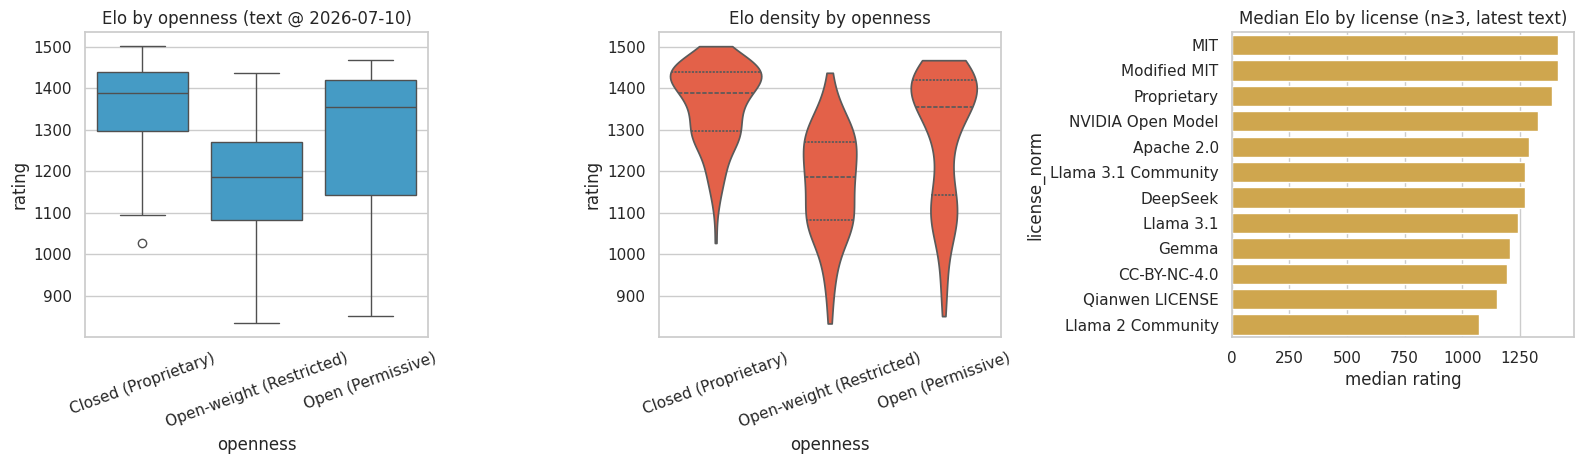

In [10]:
# Open vs closed: map normalized licenses → openness tiers
PERMISSIVE = {
    "Apache 2.0", "MIT", "Modified MIT", "OpenMDW-1.1", "AI2 ImpACT Low-risk",
}
# Weights released under vendor / community / research / NC terms (not OSI-clean, not proprietary API-only)
OPEN_WEIGHT_RESTRICTED = {
    "Llama", "Llama 2 Community", "Llama 3 Community", "Llama 3.1", "Llama 3.1 Community",
    "Llama 3.2", "Llama 4", "Llama-3.3",
    "Gemma", "Qianwen LICENSE", "DeepSeek", "CC-BY-NC-4.0", "CC-BY-NC-SA-4.0",
    "Non-commercial", "Mistral Research", "Yi License", "DBRX LICENSE",
    "Falcon-180B TII License", "NVIDIA Open Model", "Jamba Open", "MRL",
    "NexusFlow", "CogVLM2", "tencent-hunyuan-community", "MiniMax Community License",
}


def openness_tier(lic: str) -> str:
    if lic == "Proprietary":
        return "Closed (Proprietary)"
    if lic in PERMISSIVE:
        return "Open (Permissive)"
    if lic in OPEN_WEIGHT_RESTRICTED or lic == "Other":
        return "Open-weight (Restricted)"
    if lic == "Missing":
        return "Missing"
    # Fail loud on unmapped labels so new license strings get classified
    raise AssertionError(f"unmapped license_norm for openness tier: {lic!r}")


df["openness"] = df["license_norm"].map(openness_tier)
text["openness"] = text["license_norm"].map(openness_tier)
latest["license_norm"] = latest["license"].map(normalize_license)
latest["openness"] = latest["license_norm"].map(openness_tier)

OPENNESS_ORDER = [
    "Closed (Proprietary)",
    "Open-weight (Restricted)",
    "Open (Permissive)",
    "Missing",
]
# Drop Missing from comparative plots if rare
plot_tiers = [t for t in OPENNESS_ORDER if t != "Missing"]

print("Openness mix (all rows):")
display(df["openness"].value_counts().reindex(OPENNESS_ORDER).to_frame("rows"))
print("Openness mix (unique models):")
display(
    model_lic.assign(openness=lambda d: d["license_norm"].map(openness_tier))["openness"]
    .value_counts()
    .reindex(OPENNESS_ORDER)
    .to_frame("models")
)

# Summary stats on latest text board
latest_cmp = latest[latest["openness"].isin(plot_tiers)].copy()
summary = (
    latest_cmp.groupby("openness")
    .agg(
        n=("model_name", "count"),
        median_rating=("rating", "median"),
        mean_rating=("rating", "mean"),
        p90_rating=("rating", lambda s: s.quantile(0.90)),
        best=("rating", "max"),
        median_votes=("vote_count", "median"),
        median_ci=("ci_width", "median"),
    )
    .reindex(plot_tiers)
)
display(summary.round(1))

closed = latest_cmp.loc[latest_cmp["openness"] == "Closed (Proprietary)", "rating"]
openish = latest_cmp.loc[latest_cmp["openness"] != "Closed (Proprietary)", "rating"]
assert len(closed) > 5 and len(openish) > 5
u_stat, u_p = stats.mannwhitneyu(closed, openish, alternative="two-sided")
print(
    f"Mann-Whitney U (closed vs all-open-ish ratings @ latest text): "
    f"U={u_stat:.0f}, p={u_p:.3g}, "
    f"median closed={closed.median():.1f}, median open-ish={openish.median():.1f}"
)

f, ax = plt.subplots(1, 3, figsize=(16, 4.8))
sns.boxplot(
    data=latest_cmp, x="openness", y="rating", order=plot_tiers, ax=ax[0], color="#30a2da",
)
ax[0].set_title(f"Elo by openness (text @ {latest_date.date()})")
ax[0].tick_params(axis="x", rotation=20)

sns.violinplot(
    data=latest_cmp, x="openness", y="rating", order=plot_tiers, ax=ax[1],
    inner="quartile", color="#fc4f30", cut=0,
)
ax[1].set_title("Elo density by openness")
ax[1].tick_params(axis="x", rotation=20)

# Top-15 licenses on latest board by median rating (n>=3)
lic_med = (
    latest_cmp.groupby("license_norm")
    .agg(n=("rating", "count"), median_rating=("rating", "median"), best=("rating", "max"))
    .query("n >= 3")
    .sort_values("median_rating", ascending=False)
    .head(12)
)
sns.barplot(x=lic_med["median_rating"], y=lic_med.index, ax=ax[2], color="#e5ae38")
ax[2].set_title("Median Elo by license (n≥3, latest text)")
ax[2].set_xlabel("median rating")
plt.tight_layout()
plt.show()



**How to Interpret:** <br>
Three tiers, not a binary: **Closed** (API / proprietary), **Open-weight Restricted** (weights out under Llama/Gemma/NC/community terms), and **Open Permissive** (Apache/MIT-class). On the latest text board, compare medians *and* the right tail (`p90` / `best`) — open models can look fine in the middle while lagging the frontier. Mann-Whitney tests location shift between closed and all non-closed ratings; it is not a causal claim.



Latest board mix:


,222
leaderboard_publish_date,2026-07-10 00:00:00
n_models,374
closed_share,0.441176
open_share,0.558824
top10_closed,1.0
top10_open,0.0
frontier_closed,True
frontier_rating,1501.176934
best_open_rating,1467.445787
best_closed_rating,1501.176934


Share of snapshots where frontier (best Elo) is closed: 91.0%
Median closed−open best-Elo gap (positive ⇒ closed leads): 44.9


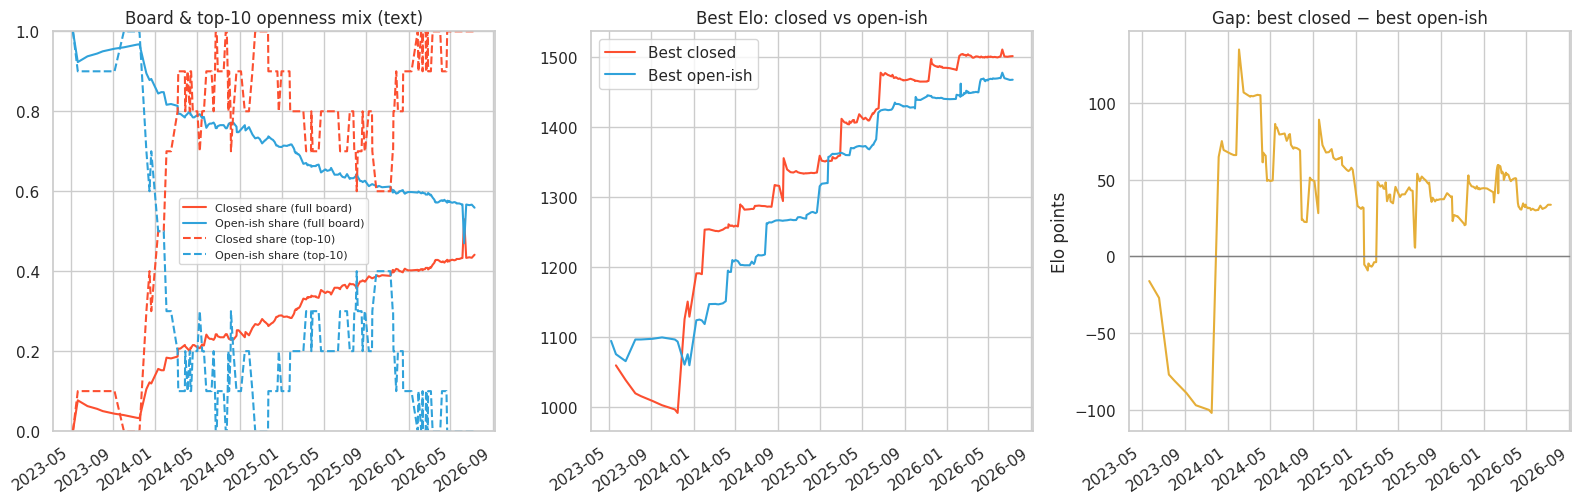

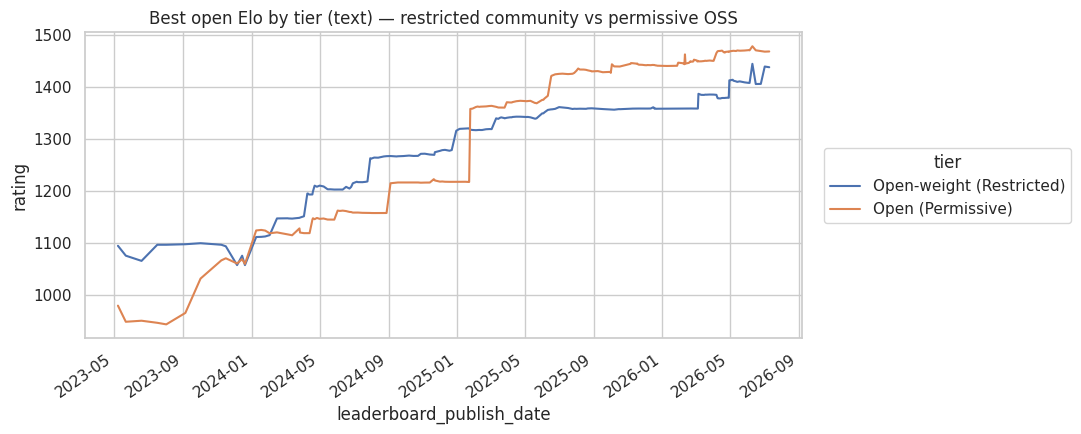

In [11]:
# Frontier composition over time: closed vs open-ish on text board
text_oc = text[text["openness"].isin(plot_tiers)].copy()
text_oc["is_closed"] = text_oc["openness"] == "Closed (Proprietary)"


def board_mix(g: pd.DataFrame) -> pd.Series:
    n = len(g)
    if g["rank"].notna().sum() >= 10:
        top10 = g.nsmallest(10, "rank")
    else:
        top10 = g.nlargest(10, "rating")
    best = g.loc[g["rating"].idxmax()]
    has_open = (~g["is_closed"]).any()
    has_closed = g["is_closed"].any()
    return pd.Series({
        "n_models": n,
        "closed_share": g["is_closed"].mean(),
        "open_share": (~g["is_closed"]).mean(),
        "top10_closed": top10["is_closed"].mean(),
        "top10_open": (~top10["is_closed"]).mean(),
        "frontier_closed": bool(best["is_closed"]),
        "frontier_rating": best["rating"],
        "best_open_rating": g.loc[~g["is_closed"], "rating"].max() if has_open else np.nan,
        "best_closed_rating": g.loc[g["is_closed"], "rating"].max() if has_closed else np.nan,
    })


mix = (
    text_oc.groupby("leaderboard_publish_date", sort=True)
    .apply(board_mix, include_groups=False)
    .reset_index()
)
mix["open_gap"] = mix["best_closed_rating"] - mix["best_open_rating"]

print("Latest board mix:")
display(mix.tail(1).T)
print(
    "Share of snapshots where frontier (best Elo) is closed:",
    f"{mix['frontier_closed'].mean():.1%}",
)
print(
    "Median closed−open best-Elo gap (positive ⇒ closed leads):",
    f"{mix['open_gap'].median():.1f}",
)


def angle_date_axis(axes):
    for a in np.atleast_1d(axes):
        a.tick_params(axis="x", labelrotation=35)
        for label in a.get_xticklabels():
            label.set_horizontalalignment("right")


f, ax = plt.subplots(1, 3, figsize=(16, 5.2))
ax[0].plot(mix["leaderboard_publish_date"], mix["closed_share"], label="Closed share (full board)", color="#fc4f30")
ax[0].plot(mix["leaderboard_publish_date"], mix["open_share"], label="Open-ish share (full board)", color="#30a2da")
ax[0].plot(mix["leaderboard_publish_date"], mix["top10_closed"], label="Closed share (top-10)", color="#fc4f30", ls="--")
ax[0].plot(mix["leaderboard_publish_date"], mix["top10_open"], label="Open-ish share (top-10)", color="#30a2da", ls="--")
ax[0].set_ylim(0, 1)
ax[0].set_title("Board & top-10 openness mix (text)")
ax[0].legend(fontsize=8)

ax[1].plot(mix["leaderboard_publish_date"], mix["best_closed_rating"], label="Best closed", color="#fc4f30")
ax[1].plot(mix["leaderboard_publish_date"], mix["best_open_rating"], label="Best open-ish", color="#30a2da")
ax[1].set_title("Best Elo: closed vs open-ish")
ax[1].legend()

ax[2].plot(mix["leaderboard_publish_date"], mix["open_gap"], color="#e5ae38")
ax[2].axhline(0, color="gray", lw=1)
ax[2].set_title("Gap: best closed − best open-ish")
ax[2].set_ylabel("Elo points")
angle_date_axis(ax)
plt.tight_layout()
plt.show()

# Tiered frontier among open models only (permissive vs restricted)
open_only = text_oc[text_oc["openness"] != "Closed (Proprietary)"]
open_best = (
    open_only.groupby(["leaderboard_publish_date", "openness"])["rating"]
    .max()
    .reset_index()
)
f, ax = plt.subplots(figsize=(11, 4.5))
sns.lineplot(
    data=open_best, x="leaderboard_publish_date", y="rating", hue="openness", ax=ax,
    hue_order=["Open-weight (Restricted)", "Open (Permissive)"],
)
ax.set_title("Best open Elo by tier (text) — restricted community vs permissive OSS")
ax.legend(title="tier", bbox_to_anchor=(1.02, 0.5), loc="center left")
angle_date_axis(ax)
plt.tight_layout()
plt.show()



**How to Interpret:** <br>
Full-board open share can rise while **top-10** stays closed-heavy — that is the difference between "many open models exist" and "open models win human preference at the frontier." The gap series (closed best − open best) tracks whether open-weight releases are catching the proprietary tip. Within open, restricted community licenses (Llama/Gemma/DeepSeek-class) usually set the open frontier; permissive Apache/MIT models are more often mid-pack.



n           median             best         
side               Closed Open-ish  Closed Open-ish  Closed Open-ish
subset                                                              
search               31.0      1.0  1179.2   1022.9  1252.9   1022.9
text                165.0    209.0  1388.0   1265.4  1501.2   1467.4
text_style_control  165.0    209.0  1399.2   1299.0  1508.6   1472.1
vision               91.0     41.0  1202.8   1137.5  1326.5   1282.6
webdev               57.0     39.0  1406.4   1363.8  1649.3   1579.6

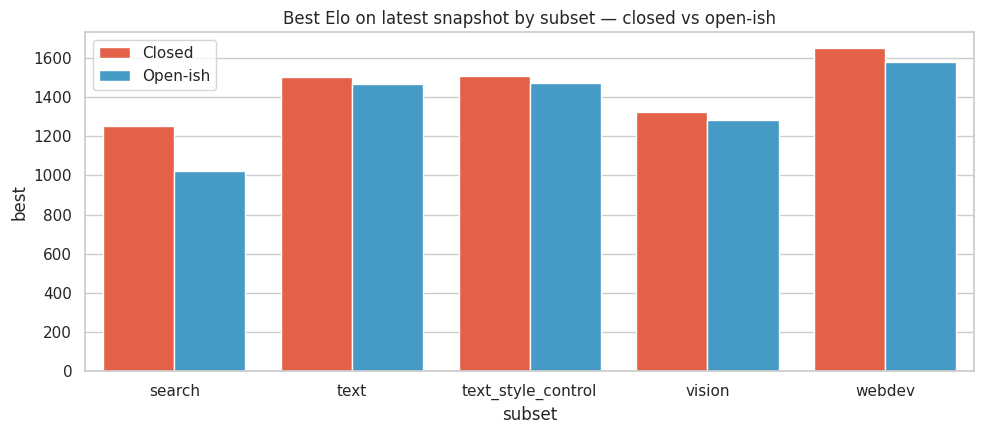

In [12]:
# Cross-subset: closed vs open-ish median / best on latest date per subset
pieces = []
for sub, g in df[df["openness"].isin(plot_tiers)].groupby("subset"):
    dmax = g["leaderboard_publish_date"].max()
    pieces.append(g.loc[g["leaderboard_publish_date"] == dmax].assign(subset=sub))
latest_sub = pd.concat(pieces, ignore_index=True)
assert latest_sub["subset"].nunique() == df["subset"].nunique()

cross = (
    latest_sub.assign(is_closed=lambda d: d["openness"] == "Closed (Proprietary)")
    .groupby(["subset", "is_closed"])
    .agg(n=("rating", "count"), median=("rating", "median"), best=("rating", "max"))
    .reset_index()
)
cross["side"] = cross["is_closed"].map({True: "Closed", False: "Open-ish"})
display(cross.pivot(index="subset", columns="side", values=["n", "median", "best"]).round(1))

f, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(
    data=cross, x="subset", y="best", hue="side",
    hue_order=["Closed", "Open-ish"], ax=ax,
    palette=["#fc4f30", "#30a2da"],
)
ax.set_title("Best Elo on latest snapshot by subset — closed vs open-ish")
ax.legend(title="")
plt.tight_layout()
plt.show()



**How to Interpret:** <br>
Each subset has its own latest calendar date and scale — compare closed vs open *within* a subset, not absolute Elo across subsets. Vision / webdev / search boards are thinner; a single strong open release can swing the "best" bar more than on text.



# **6. Votes, Uncertainty, Cross-Subset:** <a id="Votes"></a>


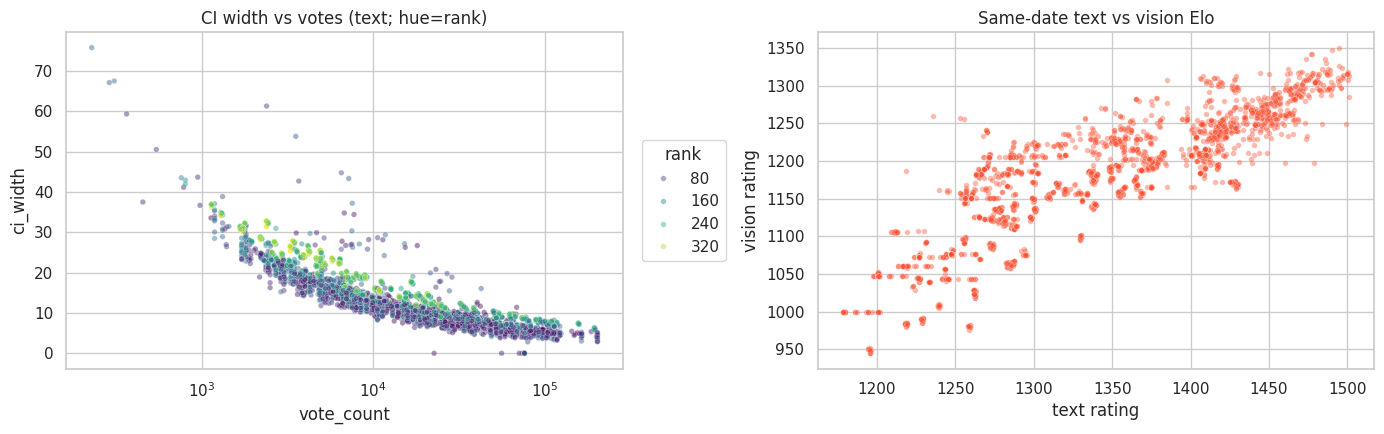

Pearson r(text, vision) same-date: 0.855
Paired model-date rows: 5299


In [13]:
voted = text.dropna(subset=["vote_count", "ci_width"])
f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.scatterplot(
    data=voted.sample(min(5000, len(voted)), random_state=7),
    x="vote_count", y="ci_width", hue="rank", palette="viridis", ax=ax[0], alpha=0.45, s=16,
)
ax[0].set_xscale("log")
ax[0].set_title("CI width vs votes (text; hue=rank)")
ax[0].legend(title="rank", bbox_to_anchor=(1.02, 0.5), loc="center left")

# Cross-subset: models present in text and vision on same date
vision = df[df["subset"] == "vision"][["model_name", "leaderboard_publish_date", "rating"]].rename(
    columns={"rating": "rating_vision"}
)
both = text[["model_name", "leaderboard_publish_date", "rating"]].merge(
    vision, on=["model_name", "leaderboard_publish_date"], how="inner"
)
assert len(both) > 0
sns.scatterplot(data=both.sample(min(3000, len(both)), random_state=7),
                x="rating", y="rating_vision", ax=ax[1], alpha=0.4, s=16, color="#fc4f30")
ax[1].set_xlabel("text rating")
ax[1].set_ylabel("vision rating")
ax[1].set_title("Same-date text vs vision Elo")
plt.tight_layout()
plt.show()
print("Pearson r(text, vision) same-date:", round(both["rating"].corr(both["rating_vision"]), 3))
print("Paired model-date rows:", len(both))


**How to Interpret:** <br>
Narrower CIs with more votes mean more stable rankings. Text–vision scatter asks whether chat strength transfers to multimodal preference on the same publish date.


# **7. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A multi-year panel of Arena overall Elo snapshots across five subset arenas, with organization and license metadata attached to each model-snapshot row.

**Working takeaways:** <br>
- Track frontiers within a subset; avoid naive cross-subset Elo comparisons.
- Org trajectories use each org's best model per date; model trajectories show named-release careers (rise, plateau, drawdown from peak).
- License univariate: Proprietary dominates unique-model share; open weight is fragmented across many community licenses (normalize Apache spellings before counting).
- Open vs closed: split **Closed / Open-weight Restricted / Open Permissive**. Full-board open share ≠ top-10 or frontier share — watch the closed−open best-Elo gap over time.
- Leave organization / CI nulls alone — early boards are thinner.

**Open follow-ups:** <br>
- Survival of top-10 membership (churn heatmaps).
- Style-control vs raw text ranking deltas for the same model.
- License changes for the few models that flip labels mid-panel.

